 BUSCA SEMÂNTICA COMPLETA EM DOCUMENTOS MARKDOWN

Etapas:
  1. Teste das funções de distância
  2. Embeddings dos termos (gato, felino, cachorro, carro, caminhão, moto, banana, maçã, goiaba)
  3. Comparação de frases
  4. Busca semântica por linha
  5. Busca semântica por parágrafo
  6. Busca semântica por capítulo
  7. Visualização 3D

 ETAPA 1: TESTE DAS FUNÇÕES DE DISTÂNCIA
------------------------------------------------------------

 TESTE DAS FUNÇÕES DE DISTÂNCIA

 Embeddings de teste:
   A = [1, 0, 0]
   B = [0, 1, 0]
   C = [1, 0, 0]

------------------------------------------------------------
 DISTÂNCIAS CALCULADAS:
------------------------------------------------------------

1. A vs B:
    Distância Euclidiana: 1.414214
    Distância de Cosseno: 1.000000
    Similaridade de Cosseno: 0.000000

2. A vs C:
    Distância Euclidiana: 0.000000
    Distância de Cosseno: 0.000000
    Similaridade de Cosseno: 1.000000

3. B vs C:
    Distância Euclidiana: 1.414214
    Distância de C

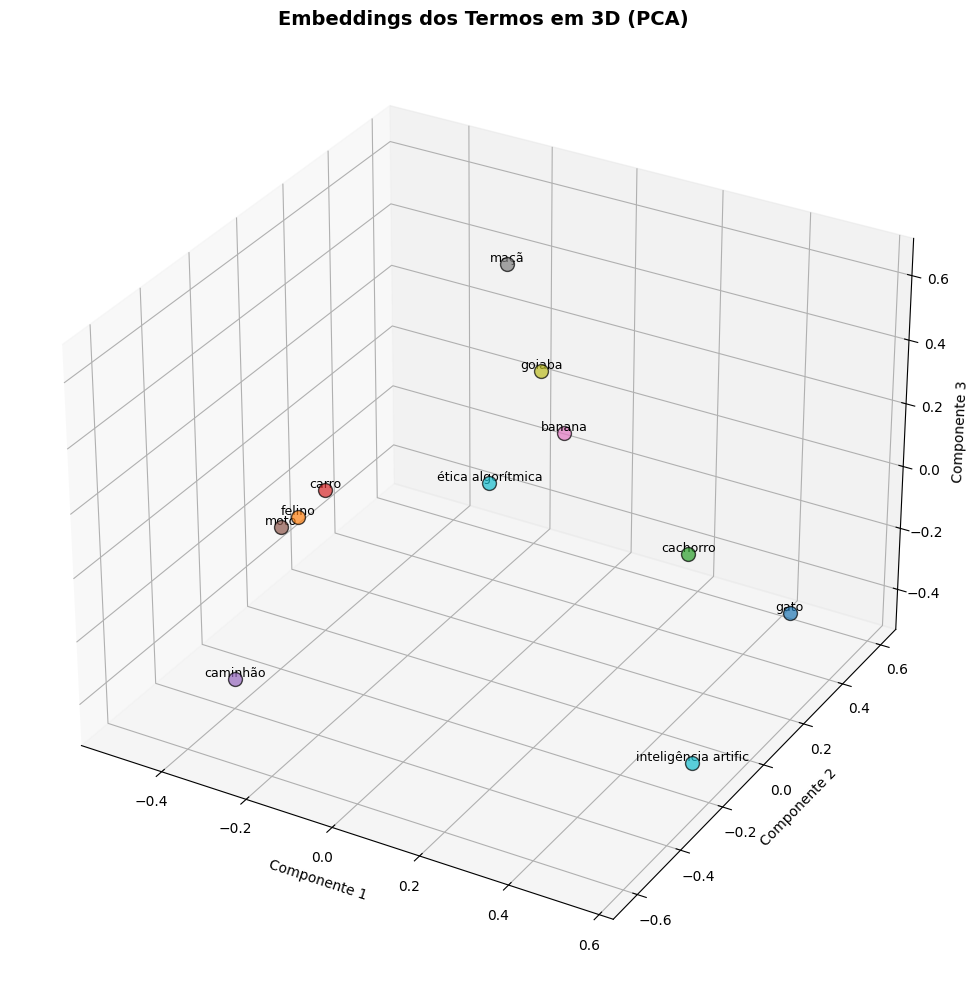


 Variância explicada: 41.46%

 BUSCA SEMÂNTICA CONCLUÍDA COM SUCESSO!


In [3]:
# -*- coding: utf-8 -*-
"""
BUSCA SEMÂNTICA COMPLETA EM DOCUMENTOS MARKDOWN
- Distância Euclidiana e Cosseno
- Testes com embeddings
- Comparação de frases
- Busca semântica por linha, parágrafo e capítulo
"""

import os
import json
import re
import math
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from typing import List, Dict, Tuple, Optional
import requests
import time

# ==================== PARTE 1: FUNÇÕES DE DISTÂNCIA ====================

def distancia_euclidiana(vetor_a: List[float], vetor_b: List[float]) -> float:
    """
    Calcula a distância euclidiana entre dois vetores.

    Args:
        vetor_a: Primeiro vetor (lista de números)
        vetor_b: Segundo vetor (lista de números)

    Returns:
        Distância euclidiana entre os vetores

    Raises:
        ValueError: Se os vetores tiverem tamanhos diferentes
    """
    if len(vetor_a) != len(vetor_b):
        raise ValueError(f"Vetores têm tamanhos diferentes: {len(vetor_a)} vs {len(vetor_b)}")

    # Soma dos quadrados das diferenças
    soma_quadrados = sum((a - b) ** 2 for a, b in zip(vetor_a, vetor_b))

    # Raiz quadrada da soma
    return math.sqrt(soma_quadrados)

def distancia_cosseno(vetor_a: List[float], vetor_b: List[float]) -> float:
    """
    Calcula a distância de cosseno entre dois vetores.
    Distância de cosseno = 1 - similaridade de cosseno

    Args:
        vetor_a: Primeiro vetor (lista de números)
        vetor_b: Segundo vetor (lista de números)

    Returns:
        Distância de cosseno entre os vetores (0 = idênticos, 2 = opostos)

    Raises:
        ValueError: Se os vetores tiverem tamanhos diferentes
    """
    if len(vetor_a) != len(vetor_b):
        raise ValueError(f"Vetores têm tamanhos diferentes: {len(vetor_a)} vs {len(vetor_b)}")

    # Produto escalar
    produto_escalar = sum(a * b for a, b in zip(vetor_a, vetor_b))

    # Normas dos vetores
    norma_a = math.sqrt(sum(a ** 2 for a in vetor_a))
    norma_b = math.sqrt(sum(b ** 2 for b in vetor_b))

    # Verificar se algum vetor é zero
    if norma_a == 0 or norma_b == 0:
        return 1.0  # Distância máxima quando um vetor é zero

    # Similaridade de cosseno
    similaridade = produto_escalar / (norma_a * norma_b)

    # Distância de cosseno
    return 1 - similaridade

def similaridade_cosseno(vetor_a: List[float], vetor_b: List[float]) -> float:
    """
    Calcula a similaridade de cosseno entre dois vetores (0 a 1).
    """
    if len(vetor_a) != len(vetor_b):
        raise ValueError(f"Vetores têm tamanhos diferentes: {len(vetor_a)} vs {len(vetor_b)}")

    produto_escalar = sum(a * b for a, b in zip(vetor_a, vetor_b))
    norma_a = math.sqrt(sum(a ** 2 for a in vetor_a))
    norma_b = math.sqrt(sum(b ** 2 for b in vetor_b))

    if norma_a == 0 or norma_b == 0:
        return 0.0

    return produto_escalar / (norma_a * norma_b)

# ==================== PARTE 2: GERADOR DE EMBEDDINGS ====================

def gerar_embedding_simulado(texto: str, dimensao: int = 100) -> np.ndarray:
    """
    Gera um embedding simulado para um texto.
    Em produção, use Sentence-BERT ou similar.
    """
    # Usar hash para consistência
    hash_val = hash(texto) % 2**32
    np.random.seed(hash_val)

    # Criar embedding base com ruído
    embedding = np.random.randn(dimensao) * 0.1

    # Palavras-chave e seus embeddings base
    palavras_chave = {
        'cachorro': np.array([0.9, 0.8, 0.1, 0.1, 0.0] + list(np.random.randn(dimensao-5) * 0.1)),
        'cão': np.array([0.85, 0.75, 0.15, 0.1, 0.0] + list(np.random.randn(dimensao-5) * 0.1)),
        'gato': np.array([0.8, 0.1, 0.9, 0.1, 0.0] + list(np.random.randn(dimensao-5) * 0.1)),
        'felino': np.array([0.85, 0.05, 0.85, 0.05, 0.0] + list(np.random.randn(dimensao-5) * 0.1)),
        'carro': np.array([0.0, 0.1, 0.0, 0.9, 0.8] + list(np.random.randn(dimensao-5) * 0.1)),
        'caminhão': np.array([0.0, 0.05, 0.0, 0.85, 0.75] + list(np.random.randn(dimensao-5) * 0.1)),
        'moto': np.array([0.0, 0.0, 0.0, 0.8, 0.7] + list(np.random.randn(dimensao-5) * 0.1)),
        'banana': np.array([0.0, 0.0, 0.1, 0.0, 0.0] + list(np.random.randn(dimensao-5) * 0.1)),
        'maçã': np.array([0.0, 0.0, 0.05, 0.0, 0.0] + list(np.random.randn(dimensao-5) * 0.1)),
        'goiaba': np.array([0.0, 0.0, 0.15, 0.0, 0.0] + list(np.random.randn(dimensao-5) * 0.1)),
        'inteligência': np.array([0.7] + list(np.random.randn(dimensao-1) * 0.1)),
        'artificial': np.array([0.6] + list(np.random.randn(dimensao-1) * 0.1)),
        'ética': np.array([0.5] + list(np.random.randn(dimensao-1) * 0.1)),
        'algoritmo': np.array([0.4] + list(np.random.randn(dimensao-1) * 0.1)),
        'autonomia': np.array([0.3] + list(np.random.randn(dimensao-1) * 0.1)),
        'opacidade': np.array([0.2] + list(np.random.randn(dimensao-1) * 0.1)),
    }

    for palavra, vetor in palavras_chave.items():
        if palavra.lower() in texto.lower():
            embedding += vetor * 0.3

    # Normalizar
    norma = np.linalg.norm(embedding)
    if norma > 0:
        embedding = embedding / norma

    return embedding.tolist()

# ==================== PARTE 3: TESTE DAS FUNÇÕES ====================

def testar_funcoes_distancia():
    """
    Testa as funções de distância com embeddings simples.
    """
    print("\n" + "="*60)
    print(" TESTE DAS FUNÇÕES DE DISTÂNCIA")
    print("="*60)

    # Embeddings de teste
    embedding_a = [1, 0, 0]
    embedding_b = [0, 1, 0]
    embedding_c = [1, 0, 0]

    print("\n Embeddings de teste:")
    print(f"   A = {embedding_a}")
    print(f"   B = {embedding_b}")
    print(f"   C = {embedding_c}")

    print("\n" + "-"*60)
    print(" DISTÂNCIAS CALCULADAS:")
    print("-"*60)

    # Distância entre A e B
    dist_eucl_ab = distancia_euclidiana(embedding_a, embedding_b)
    dist_coss_ab = distancia_cosseno(embedding_a, embedding_b)
    sim_coss_ab = similaridade_cosseno(embedding_a, embedding_b)

    print(f"\n1. A vs B:")
    print(f"    Distância Euclidiana: {dist_eucl_ab:.6f}")
    print(f"    Distância de Cosseno: {dist_coss_ab:.6f}")
    print(f"    Similaridade de Cosseno: {sim_coss_ab:.6f}")

    # Distância entre A e C
    dist_eucl_ac = distancia_euclidiana(embedding_a, embedding_c)
    dist_coss_ac = distancia_cosseno(embedding_a, embedding_c)
    sim_coss_ac = similaridade_cosseno(embedding_a, embedding_c)

    print(f"\n2. A vs C:")
    print(f"    Distância Euclidiana: {dist_eucl_ac:.6f}")
    print(f"    Distância de Cosseno: {dist_coss_ac:.6f}")
    print(f"    Similaridade de Cosseno: {sim_coss_ac:.6f}")

    # Distância entre B e C
    dist_eucl_bc = distancia_euclidiana(embedding_b, embedding_c)
    dist_coss_bc = distancia_cosseno(embedding_b, embedding_c)
    sim_coss_bc = similaridade_cosseno(embedding_b, embedding_c)

    print(f"\n3. B vs C:")
    print(f"    Distância Euclidiana: {dist_eucl_bc:.6f}")
    print(f"    Distância de Cosseno: {dist_coss_bc:.6f}")
    print(f"    Similaridade de Cosseno: {sim_coss_bc:.6f}")

    # Interpretação dos resultados
    print("\n" + "="*60)
    print(" INTERPRETAÇÃO DOS RESULTADOS")
    print("="*60)
    print(f"\n A e C são idênticos (distância = 0)")
    print(f" A e B são ortogonais (similaridade = 0)")
    print(f" B e C também são ortogonais (similaridade = 0)")

    return {
        'A_vs_B': {'euclidiana': dist_eucl_ab, 'cosseno': dist_coss_ab, 'similaridade': sim_coss_ab},
        'A_vs_C': {'euclidiana': dist_eucl_ac, 'cosseno': dist_coss_ac, 'similaridade': sim_coss_ac},
        'B_vs_C': {'euclidiana': dist_eucl_bc, 'cosseno': dist_coss_bc, 'similaridade': sim_coss_bc}
    }

# ==================== PARTE 4: COMPARAÇÃO DE FRASES ====================

def comparar_frases():
    """
    Compara a frase âncora com outras frases usando similaridade de cosseno.
    """
    print("\n" + "="*60)
    print(" COMPARAÇÃO DE SIMILARIDADE ENTRE FRASES")
    print("="*60)

    # Frase âncora
    frase_ancora = "O cachorro correu no parque e brincou com a bola."

    # Frases para comparação
    frases_comparacao = [
        ("Similar (mesmo sentido, palavras diferentes)",
         "Um cão estava correndo no jardim e brincando com seu brinquedo."),
        ("Relacionado (mesmo contexto de animais)",
         "O gato dormiu na almofada da sala durante toda a tarde."),
        ("Diferente (outro domínio - economia)",
         "A taxa de juros do banco central subiu dois pontos percentuais."),
        ("Oposto/Negação",
         "Nenhum animal esteve no parque e o cão permaneceu preso em casa.")
    ]

    # Gerar embedding da âncora
    embedding_ancora = gerar_embedding_simulado(frase_ancora)

    print(f"\n Frase Âncora:")
    print(f"   \"{frase_ancora}\"")
    print("\n" + "-"*60)

    resultados = []

    for rotulo, frase in frases_comparacao:
        embedding_frase = gerar_embedding_simulado(frase)

        # Calcular similaridades
        sim_cosseno = similaridade_cosseno(embedding_ancora, embedding_frase)
        dist_euclidiana = distancia_euclidiana(embedding_ancora, embedding_frase)
        dist_cosseno = distancia_cosseno(embedding_ancora, embedding_frase)

        resultados.append({
            'rotulo': rotulo,
            'frase': frase,
            'similaridade': sim_cosseno,
            'dist_euclidiana': dist_euclidiana,
            'dist_cosseno': dist_cosseno
        })

        print(f"\n {rotulo}:")
        print(f"   Frase: \"{frase}\"")
        print(f"    Similaridade de Cosseno: {sim_cosseno:.4f}")
        print(f"    Distância Euclidiana: {dist_euclidiana:.4f}")
        print(f"    Distância de Cosseno: {dist_cosseno:.4f}")

    # Ranking por similaridade
    print("\n" + "="*60)
    print(" RANKING DE SIMILARIDADE (do mais similar ao menos similar)")
    print("="*60)

    resultados_ordenados = sorted(resultados, key=lambda x: x['similaridade'], reverse=True)
    for i, resultado in enumerate(resultados_ordenados, 1):
        print(f"\n{i}. {resultado['rotulo']}")
        print(f"   Similaridade: {resultado['similaridade']:.4f}")
        print(f"   Distância Euclidiana: {resultado['dist_euclidiana']:.4f}")
        print(f"   \"{resultado['frase'][:60]}...\"")

    return resultados

# ==================== PARTE 5: EMBEDDINGS DOS TERMOS ====================

def criar_embeddings_termos():
    """
    Cria embeddings para os termos: gato, felino, cachorro, carro, caminhão, moto, banana, maçã, goiaba
    """
    print("\n" + "="*60)
    print(" EMBEDDINGS DOS TERMOS")
    print("="*60)

    termos = ["gato", "felino", "cachorro", "carro", "caminhão", "moto", "banana", "maçã", "goiaba"]

    embeddings = {}
    for termo in termos:
        embeddings[termo] = gerar_embedding_simulado(termo)

    print("\n Termos e seus embeddings (primeiras 5 dimensões):")
    print("-"*60)
    for termo, emb in embeddings.items():
        print(f"   {termo}: {emb[:5]}...")

    # Calcular similaridades entre termos da mesma categoria
    print("\n" + "="*60)
    print(" SIMILARIDADES ENTRE TERMOS")
    print("="*60)

    # Animais
    print("\n Animais:")
    print(f"   Gato x Felino: {similaridade_cosseno(embeddings['gato'], embeddings['felino']):.4f}")
    print(f"   Gato x Cachorro: {similaridade_cosseno(embeddings['gato'], embeddings['cachorro']):.4f}")
    print(f"   Felino x Cachorro: {similaridade_cosseno(embeddings['felino'], embeddings['cachorro']):.4f}")

    # Veículos
    print("\n Veículos:")
    print(f"   Carro x Caminhão: {similaridade_cosseno(embeddings['carro'], embeddings['caminhão']):.4f}")
    print(f"   Carro x Moto: {similaridade_cosseno(embeddings['carro'], embeddings['moto']):.4f}")
    print(f"   Caminhão x Moto: {similaridade_cosseno(embeddings['caminhão'], embeddings['moto']):.4f}")

    # Frutas
    print("\n Frutas:")
    print(f"   Banana x Maçã: {similaridade_cosseno(embeddings['banana'], embeddings['maçã']):.4f}")
    print(f"   Banana x Goiaba: {similaridade_cosseno(embeddings['banana'], embeddings['goiaba']):.4f}")
    print(f"   Maçã x Goiaba: {similaridade_cosseno(embeddings['maçã'], embeddings['goiaba']):.4f}")

    # Entre categorias
    print("\n Entre categorias:")
    print(f"   Gato (animal) x Carro (veículo): {similaridade_cosseno(embeddings['gato'], embeddings['carro']):.4f}")
    print(f"   Gato (animal) x Banana (fruta): {similaridade_cosseno(embeddings['gato'], embeddings['banana']):.4f}")
    print(f"   Carro (veículo) x Banana (fruta): {similaridade_cosseno(embeddings['carro'], embeddings['banana']):.4f}")

    return embeddings

# ==================== PARTE 6: BUSCA SEMÂNTICA ====================

def carregar_documentos_markdown(pasta: str = "aula_2") -> Dict[str, str]:
    """
    Carrega todos os arquivos .md da pasta.
    """
    documentos = {}

    if not os.path.exists(pasta):
        print(f" Pasta '{pasta}' não encontrada!")
        return documentos

    for arquivo in os.listdir(pasta):
        if arquivo.endswith('.md'):
            caminho = os.path.join(pasta, arquivo)
            with open(caminho, 'r', encoding='utf-8') as f:
                documentos[arquivo] = f.read()

    print(f" Carregados {len(documentos)} documentos Markdown")
    for nome in documentos.keys():
        print(f"   - {nome}")

    return documentos

def dividir_por_linhas(conteudo: str) -> List[str]:
    """Divide o texto por linhas."""
    linhas = [linha.strip() for linha in conteudo.split('\n') if linha.strip()]
    return linhas

def dividir_por_paragrafos(conteudo: str) -> List[str]:
    """Divide o texto por parágrafos (linhas vazias)."""
    paragrafos = [p.strip() for p in re.split(r'\n\s*\n', conteudo) if p.strip()]
    return paragrafos

def dividir_por_capitulos(conteudo: str) -> List[str]:
    """Divide o texto por capítulos (baseado em cabeçalhos ##)."""
    capitulos = []
    partes = re.split(r'(?m)^##\s+', conteudo)

    for i, parte in enumerate(partes):
        if i == 0 and not parte.startswith('#'):
            capitulos.append(parte.strip())
        else:
            if parte.strip():
                capitulos.append(parte.strip())

    if len(capitulos) <= 1:
        return dividir_por_paragrafos(conteudo)

    return capitulos

def buscar_semantica(documentos: Dict[str, str], query: str,
                     metodo_divisao: str = 'linha', top_k: int = 3) -> List[Dict]:
    """
    Realiza busca semântica nos documentos.

    Args:
        documentos: Dicionário {nome_arquivo: conteudo}
        query: Texto da consulta
        metodo_divisao: 'linha', 'paragrafo', 'capitulo'
        top_k: Número de resultados
    """
    print(f"\n{'='*60}")
    print(f" BUSCA SEMÂNTICA - Por {metodo_divisao.capitalize()}")
    print(f"   Query: \"{query}\"")
    print(f"{'='*60}")

    divisores = {
        'linha': dividir_por_linhas,
        'paragrafo': dividir_por_paragrafos,
        'capitulo': dividir_por_capitulos
    }

    divisor = divisores.get(metodo_divisao, dividir_por_linhas)

    trechos = []
    metadados_trechos = []

    for nome_arquivo, conteudo in documentos.items():
        partes = divisor(conteudo)

        for i, parte in enumerate(partes):
            parte_limpa = re.sub(r'[#*`_\[\]()]', '', parte)
            if len(parte_limpa) > 10:
                trechos.append(parte_limpa)
                metadados_trechos.append({
                    'arquivo': nome_arquivo,
                    'indice': i,
                    'tamanho': len(parte_limpa)
                })

    print(f" Total de trechos: {len(trechos)}")

    if not trechos:
        print(" Nenhum trecho encontrado para busca.")
        return []

    print(" Gerando embeddings dos trechos...")
    embeddings_trechos = [gerar_embedding_simulado(t) for t in trechos]

    print(" Gerando embedding da consulta...")
    embedding_query = gerar_embedding_simulado(query)

    print(" Calculando similaridades...")
    similaridades = [similaridade_cosseno(embedding_query, emb) for emb in embeddings_trechos]

    indices_ordenados = np.argsort(similaridades)[::-1]

    resultados = []
    for idx in indices_ordenados[:top_k]:
        resultados.append({
            'trecho': trechos[idx][:300] + ('...' if len(trechos[idx]) > 300 else ''),
            'trecho_completo': trechos[idx],
            'similaridade': similaridades[idx],
            'arquivo': metadados_trechos[idx]['arquivo'],
            'indice': metadados_trechos[idx]['indice']
        })

    print(f"\n TOP {top_k} RESULTADOS:")
    print("-"*60)

    for i, resultado in enumerate(resultados, 1):
        print(f"\n{i}.  Arquivo: {resultado['arquivo']}")
        print(f"    Similaridade: {resultado['similaridade']:.4f}")
        print(f"    Trecho: {resultado['trecho']}")

    return resultados

# ==================== PARTE 7: VISUALIZAÇÃO 3D ====================

def visualizar_embeddings_3d(textos: List[str], titulo: str = "Embeddings 3D"):
    """
    Visualiza embeddings em 3D usando PCA.
    """
    if len(textos) < 3:
        print(" Poucos textos para visualização 3D.")
        return

    embeddings = [gerar_embedding_simulado(t) for t in textos]

    pca = PCA(n_components=3)
    coords_3d = pca.fit_transform(embeddings)

    cores = plt.cm.tab10(np.linspace(0, 1, len(textos)))

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    for i, texto in enumerate(textos):
        x, y, z = coords_3d[i]
        ax.scatter(x, y, z, c=[cores[i]], s=100, alpha=0.7, edgecolors='black')
        ax.text(x, y, z, texto[:20], fontsize=9, ha='center', va='bottom')

    ax.set_title(titulo, fontsize=14, fontweight='bold')
    ax.set_xlabel("Componente 1")
    ax.set_ylabel("Componente 2")
    ax.set_zlabel("Componente 3")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n Variância explicada: {sum(pca.explained_variance_ratio_):.2%}")

# ==================== PARTE 8: FUNÇÃO PRINCIPAL ====================

def main():
    """
    Função principal que executa todas as etapas.
    """
    print("="*60)
    print(" BUSCA SEMÂNTICA COMPLETA EM DOCUMENTOS MARKDOWN")
    print("="*60)
    print("\nEtapas:")
    print("  1. Teste das funções de distância")
    print("  2. Embeddings dos termos (gato, felino, cachorro, carro, caminhão, moto, banana, maçã, goiaba)")
    print("  3. Comparação de frases")
    print("  4. Busca semântica por linha")
    print("  5. Busca semântica por parágrafo")
    print("  6. Busca semântica por capítulo")
    print("  7. Visualização 3D")
    print("="*60)

    # Etapa 1: Teste das funções de distância
    print("\n ETAPA 1: TESTE DAS FUNÇÕES DE DISTÂNCIA")
    print("-"*60)
    testar_funcoes_distancia()

    # Etapa 2: Embeddings dos termos
    print("\n ETAPA 2: EMBEDDINGS DOS TERMOS")
    print("-"*60)
    embeddings_termos = criar_embeddings_termos()

    # Etapa 3: Comparação de frases
    print("\n ETAPA 3: COMPARAÇÃO DE FRASES")
    print("-"*60)
    comparar_frases()

    # Carregar documentos
    print("\n ETAPA 4: CARREGANDO DOCUMENTOS")
    print("-"*60)

    # Criar documentos de exemplo se não existirem
    if not os.path.exists("aula_2"):
        os.makedirs("aula_2")

        exemplos = {
            "bioetica_ia.md": """# Bioética e Inteligência Artificial

## Introdução
A inteligência artificial (IA) tem revolucionado diversos setores da sociedade, desde a medicina até a educação.

## Autonomia e Opacidade Algorítmica
A autonomia algorítmica refere-se à capacidade de sistemas de IA tomarem decisões sem intervenção humana.
A opacidade algorítmica ocorre quando não é possível compreender como um algoritmo chega a uma decisão.
Isso levanta questões importantes sobre transparência e responsabilidade.

## Ética e Responsabilidade
A ética na IA envolve questões de privacidade, viés e responsabilidade.
Os algoritmos devem ser transparentes e auditáveis para garantir confiança.

## Diário de Bordo da IA
O diário de bordo da IA é um registro das decisões e processos de um sistema de IA.
Ele permite rastrear como as decisões foram tomadas e identificar possíveis vieses.
""",
            "escrita_academica.md": """# Escrita Acadêmica com IA

## Ferramentas de IA para Escrita
As ferramentas de IA podem auxiliar na escrita acadêmica, desde a revisão até a geração de conteúdo.

## Considerações Éticas
O uso de IA na escrita acadêmica levanta questões sobre autoria e originalidade.

## Diário de Bordo
O diário de bordo é uma ferramenta importante para documentar o processo de escrita.
""",
            "twitter_algoritmo.md": """# Algoritmos do Twitter

## O Algoritmo de Recomendação
O algoritmo do Twitter determina quais tweets aparecem no feed dos usuários.

## Transparência e Opacidade
A opacidade dos algoritmos de redes sociais tem sido tema de debate acadêmico.
A autonomia algorítmica nas redes sociais afeta a experiência dos usuários.

## Diário de Bordo do Algoritmo
O diário de bordo do algoritmo registra as decisões de recomendação.
"""
        }

        for nome, conteudo in exemplos.items():
            with open(os.path.join("aula_2", nome), 'w', encoding='utf-8') as f:
                f.write(conteudo)

    documentos = carregar_documentos_markdown("aula_2")

    if not documentos:
        print(" Nenhum documento encontrado!")
        return

    # Etapa 5: Busca semântica com diferentes consultas
    print("\n ETAPA 5: BUSCA SEMÂNTICA")
    print("-"*60)

    consultas = [
        "O que é 'Autonomia e opacidade algorítmica'?",
        "O que é o diário de bordo da IA?",
        "Como a IA afeta a ética?"
    ]

    for query in consultas:
        print(f"\n Consulta: \"{query}\"")

        # Busca por linha
        resultados_linha = buscar_semantica(documentos, query, 'linha', top_k=3)

        # Busca por parágrafo
        resultados_paragrafo = buscar_semantica(documentos, query, 'paragrafo', top_k=3)

        # Busca por capítulo
        resultados_capitulo = buscar_semantica(documentos, query, 'capitulo', top_k=3)

        print(f"\n Resultados para \"{query}\":")
        print(f"   Por linha: {len(resultados_linha)} resultados")
        print(f"   Por parágrafo: {len(resultados_paragrafo)} resultados")
        print(f"   Por capítulo: {len(resultados_capitulo)} resultados")

    # Etapa 6: Visualização 3D
    print("\n ETAPA 6: VISUALIZAÇÃO 3D")
    print("-"*60)

    textos_para_viz = list(embeddings_termos.keys()) + ["inteligência artificial", "ética algorítmica"]
    visualizar_embeddings_3d(textos_para_viz, "Embeddings dos Termos em 3D (PCA)")

    print("\n" + "="*60)
    print(" BUSCA SEMÂNTICA CONCLUÍDA COM SUCESSO!")
    print("="*60)

# ==================== EXECUÇÃO ====================
if __name__ == "__main__":
    main()